# Phase offsets for aligning signals to the voltage cycle

**The problem.** Each VSB recording covers exactly one 50 Hz cycle (20 ms), but recordings start at different points of the voltage wave: some start near a peak, some near a zero crossing, some rising, some falling. Until now, chunk positions were measured from the start of each recording, so the same PD pattern could appear at different chunk positions in different signals. PD is linked to specific points of the voltage cycle, so this makes position harder for the models to learn.

**The fix.** For every signal, estimate where the recording sits in the voltage cycle, and shift it so all signals start at the same point: the **positive-going zero crossing** (0° of the voltage cycle). After alignment, chunk *k* corresponds to the same voltage phase angle (k × 2.25°) in every signal.

**What this notebook does.** It only calculates each signal's offset and saves it in a small table; it does **not** redo the filtering, denoising and feature extraction. The training notebook (Test 4) then shifts the already-saved v2 features. This takes roughly 20–30 minutes instead of 1–2 hours.

**Before running:** attach the competition data. No GPU is needed. Run once with `LIMIT = 60` as a quick test, then set `LIMIT = None` and commit with **Save & Run All**.

## 1. Settings

In [1]:
import glob
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pywt
import matplotlib.pyplot as plt
from scipy import signal
from tqdm.auto import tqdm

OUT_DIR = '/kaggle/working'
LIMIT = 60                 # quick test; set to None for all signals

N_SAMPLES = 800_000
FS = N_SAMPLES / 0.02      # 40 MHz
N_CHUNKS = 160
CHUNK_LEN = N_SAMPLES // N_CHUNKS
DEG_PER_CHUNK = 360 / N_CHUNKS   # 2.25 degrees

raw_meta = glob.glob('/kaggle/input/**/metadata_train.csv', recursive=True)
assert raw_meta, 'Competition data not found: Add Input > Competition Datasets > vsb-power-line-fault-detection'
DATA_DIR = raw_meta[0].rsplit('/', 1)[0]
meta = pd.read_csv(f'{DATA_DIR}/metadata_train.csv')
meta_k = pd.read_csv(f'{DATA_DIR}/metadata_test.csv')
print('Data from', DATA_DIR, '| labelled:', len(meta), '| Kaggle test:', len(meta_k))

Data from /kaggle/input/competitions/vsb-power-line-fault-detection | labelled: 8712 | Kaggle test: 20337


## 2. Estimating where a recording sits in the voltage cycle

Each raw signal is dominated by the 50 Hz voltage wave. Because a recording is exactly one cycle long, the 50 Hz component is the **first harmonic** of the recording, and its phase can be found with a single Fourier coefficient (multiplying the signal by a cosine and a sine of one cycle and summing):

- The signal is approximately `A·cos(2πn/N + φ)`, where φ is the phase at the first sample.
- The positive-going zero crossing is where the wave equals `A·sin(0)`, i.e. where `2πn/N + φ + π/2 = 0` (modulo one cycle).
- Shifting the signal left by that many samples makes it start at the zero crossing.

The shift is also expressed in chunks (shift ÷ 5,000, rounded), since the saved features are per chunk. Rounding to the nearest chunk means an alignment error of at most ±1.1°, which is negligible.

`amplitude` (A) is saved too: if a signal's 50 Hz wave is very weak, its phase estimate is less reliable.

In [2]:
n = np.arange(N_SAMPLES)
COS = np.cos(2 * np.pi * n / N_SAMPLES).astype(np.float32)
SIN = np.sin(2 * np.pi * n / N_SAMPLES).astype(np.float32)

def phase_offset(raw):
    x = raw.astype(np.float32)
    a, b = float(x @ COS), float(x @ SIN)
    amplitude = 2 * np.hypot(a, b) / N_SAMPLES
    phi = np.arctan2(-b, a)                                     # x ≈ A·cos(2πn/N + φ)
    shift = int(round(((-(phi + np.pi / 2)) % (2 * np.pi)) / (2 * np.pi) * N_SAMPLES)) % N_SAMPLES
    return phi, amplitude, shift

def align(raw, shift):
    return np.roll(raw, -shift)

## 3. Visual check

Four labelled signals, before and after alignment (every 200th sample is plotted, which is enough to see the 50 Hz wave). Before: the waves start at different points. After: all start at zero and rise.

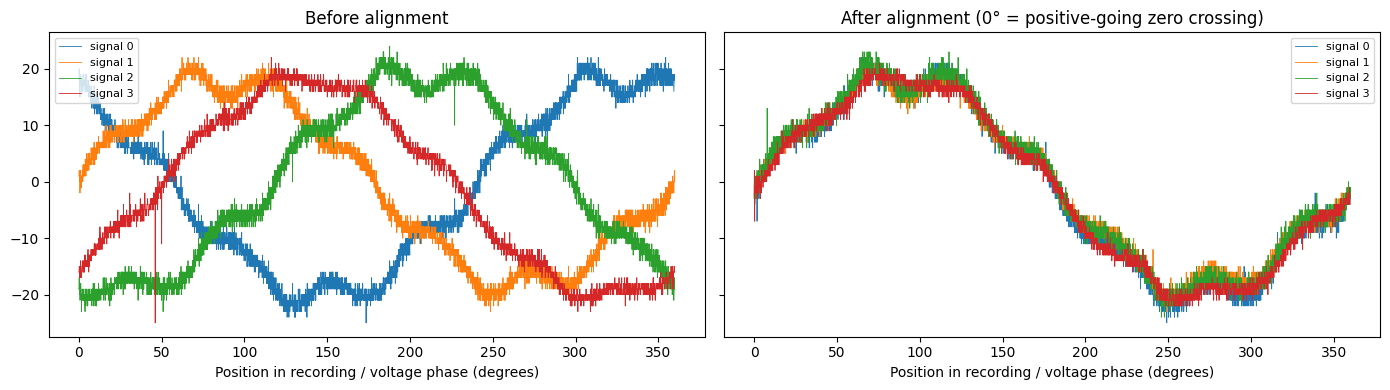

In [3]:
ids = meta['signal_id'].values[:4]
table = pq.read_table(f'{DATA_DIR}/train.parquet', columns=[str(s) for s in ids])
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
deg = np.arange(0, N_SAMPLES, 200) / N_SAMPLES * 360
for s in ids:
    raw = table.column(str(s)).to_numpy()
    _, _, shift = phase_offset(raw)
    axes[0].plot(deg, raw[::200], linewidth=0.6, label=f'signal {s}')
    axes[1].plot(deg, align(raw, shift)[::200], linewidth=0.6, label=f'signal {s}')
axes[0].set_title('Before alignment'); axes[1].set_title('After alignment (0° = positive-going zero crossing)')
for ax in axes:
    ax.set_xlabel('Position in recording / voltage phase (degrees)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Calculate and save the offsets for every signal

Only the raw signals are read (300 at a time) and one Fourier coefficient is calculated per signal, so this is much faster than the full preprocessing.

Outputs: `phase_offsets_train.csv` and `phase_offsets_kaggle_test.csv`, each with `signal_id`, `phi_rad`, `amplitude`, `shift_samples` and `shift_chunks`.

In [4]:
def offsets(parquet_file, ids):
    rows = []
    for start in tqdm(range(0, len(ids), 300), desc=parquet_file):
        batch = ids[start:start + 300]
        table = pq.read_table(f'{DATA_DIR}/{parquet_file}', columns=[str(s) for s in batch])
        for s in batch:
            phi, amp, shift = phase_offset(table.column(str(s)).to_numpy())
            rows.append((s, phi, amp, shift, int(round(shift / CHUNK_LEN)) % N_CHUNKS))
        del table
    return pd.DataFrame(rows, columns=['signal_id', 'phi_rad', 'amplitude', 'shift_samples', 'shift_chunks'])

run_meta = meta.iloc[:LIMIT] if LIMIT else meta
run_k = meta_k.iloc[:LIMIT] if LIMIT else meta_k
off_train = offsets('train.parquet', run_meta['signal_id'].values)
off_k = offsets('test.parquet', run_k['signal_id'].values)
off_train.to_csv(f'{OUT_DIR}/phase_offsets_train.csv', index=False)
off_k.to_csv(f'{OUT_DIR}/phase_offsets_kaggle_test.csv', index=False)
print('Saved offsets:', len(off_train), 'labelled,', len(off_k), 'Kaggle test')

train.parquet:   0%|          | 0/1 [00:00<?, ?it/s]

test.parquet:   0%|          | 0/1 [00:00<?, ?it/s]

Saved offsets: 60 labelled, 60 Kaggle test


## 5. Checks

- **Histogram of start positions:** if recordings started at the same point of the cycle, all shifts would be equal. A spread across 0–360° confirms alignment is needed.
- **Weak 50 Hz waves:** signals whose 50 Hz amplitude is under 10% of the median, where the phase estimate may be unreliable.

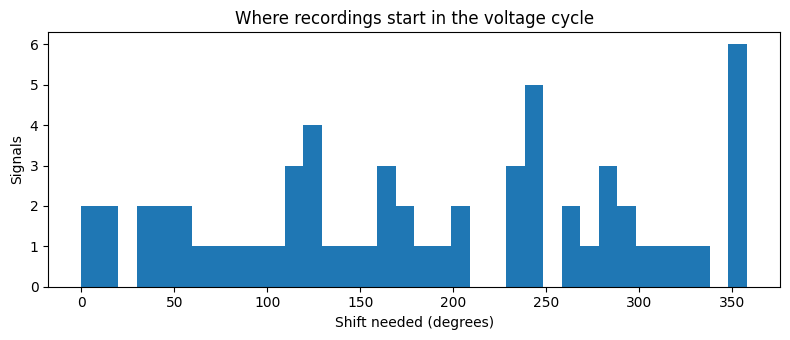

Median 50 Hz amplitude: 19.9 | signals with a weak 50 Hz wave: 0 of 120


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(off_train['shift_chunks'] * DEG_PER_CHUNK, bins=36, color='tab:blue')
ax.set_xlabel('Shift needed (degrees)'); ax.set_ylabel('Signals'); ax.set_title('Where recordings start in the voltage cycle')
plt.tight_layout(); plt.show()

amp = pd.concat([off_train['amplitude'], off_k['amplitude']])
weak = (amp < 0.1 * amp.median()).sum()
print(f'Median 50 Hz amplitude: {amp.median():.1f} | signals with a weak 50 Hz wave: {weak} of {len(amp)}')

## 6. Corrected phase angles for signal 3

Earlier, the pulse clusters of signal 3 were described at about 45° and 225°, but those positions were measured from the start of the recording. Here, signal 3's pulses are counted again and plotted against the **true voltage phase angle** after alignment.

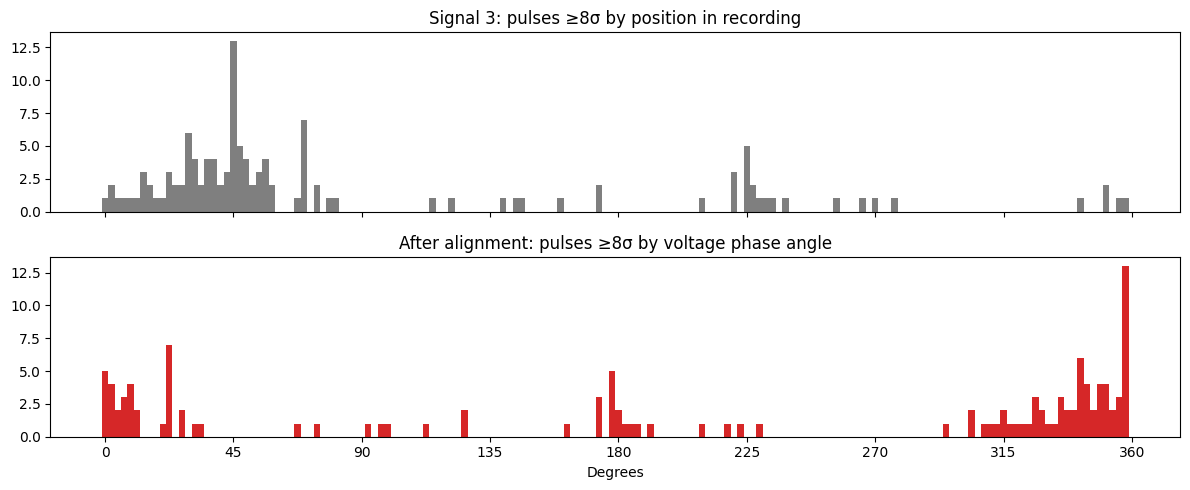

Shift for signal 3: 47.4° | busiest voltage phase angles: [22.5, 342.0, 357.8]


In [6]:
SOS = signal.butter(5, 10_000, btype='highpass', fs=FS, output='sos')
def wavelet_denoise(x, wavelet='db4', level=1):
    coeffs = pywt.wavedec(x, wavelet, mode='per', level=level)
    sigma = np.median(np.abs(coeffs[-1] - np.median(coeffs[-1]))) / 0.6745
    coeffs[1:] = [pywt.threshold(c, value=sigma * np.sqrt(2 * np.log(len(x))), mode='hard') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet, mode='per')[:len(x)]

sid = meta.loc[meta['target'] == 1, 'signal_id'].iloc[0]
raw = pq.read_table(f'{DATA_DIR}/train.parquet', columns=[str(sid)]).column(0).to_numpy()
_, _, shift = phase_offset(raw)
x = wavelet_denoise(signal.sosfiltfilt(SOS, raw.astype(np.float32)))
z = x / (np.median(np.abs(x - np.median(x))) / 0.6745 + 1e-9)
peaks, _ = signal.find_peaks(np.abs(z), height=8, distance=20)
counts = np.bincount(peaks // CHUNK_LEN, minlength=N_CHUNKS)
counts_aligned = np.roll(counts, -int(round(shift / CHUNK_LEN)))

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
angles = np.arange(N_CHUNKS) * DEG_PER_CHUNK
axes[0].bar(angles, counts, width=DEG_PER_CHUNK, color='tab:gray'); axes[0].set_title(f'Signal {sid}: pulses ≥8σ by position in recording')
axes[1].bar(angles, counts_aligned, width=DEG_PER_CHUNK, color='tab:red'); axes[1].set_title('After alignment: pulses ≥8σ by voltage phase angle')
axes[1].set_xlabel('Degrees'); axes[1].set_xticks(range(0, 361, 45))
plt.tight_layout(); plt.show()
top = np.argsort(counts_aligned)[::-1][:3] * DEG_PER_CHUNK
print(f'Shift for signal {sid}: {(shift * 360 / N_SAMPLES) % 360:.1f}° | busiest voltage phase angles: {sorted(round(float(a), 1) for a in top)}')